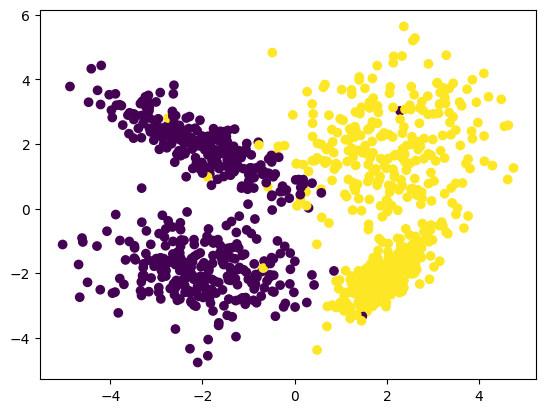

Accuracy:  0.976
F1:  0.9761431411530815


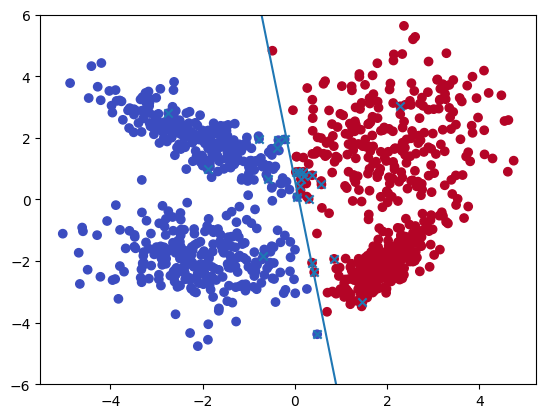

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, f1_score

X, Y = make_classification (n_samples=1000,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_classes=2,
                          class_sep=2,
                          random_state=1)

plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()

class SGD():
    def __init__(self, alpha=0.5, n_iter=1000):
        self.alpha = alpha
        self.n_iter = n_iter
        self.w = None

    def gradient_step(self, w, grad):
        return w - self.alpha * grad

    def optimize(self, X, Y, start_w, n_iter):
        w = start_w.copy()
        for i in range(n_iter):
            grad = self.grad_func(X, Y, w)
            w = self.gradient_step(w, grad)
        return w

    def fit(self, X, Y):
        X_bias = np.hstack((np.ones((X.shape[0], 1)), X))
        start_w = np.ones(X_bias.shape[1])
        self.w = self.optimize(X_bias, Y, start_w, self.n_iter)
        self.X_bias = X_bias

class Logreg(SGD):
    def sigmoid(self, X, w):
        return 1 / (1 + np.exp(-X.dot(w)))

    def grad_func(self, X, Y, w):
        return 1 / X.shape[0] * X.T.dot(self.sigmoid(X, w) - Y)
    def predict_proba(self, X):
        X_bias = np.hstack((np.ones((X.shape[0], 1)), X))
        return self.sigmoid(X_bias, self.w)
    def predict(self, X):
        return self.predict_proba(X) > 0.5


logreg = Logreg()


logreg.fit(X, Y)
pred = logreg.predict(X)
wrong = pred != Y

w0, w1, w2 = logreg.w
x_val =  np.array([X[:, 0].min(), X[:, 0].max()])
y_val = -(w0 + w1 * x_val) / w2

acc = accuracy_score(Y, pred)
f1 = f1_score(Y, pred)

print("Accuracy: ", acc)
print("F1: ", f1)

plt.scatter(X[:, 0], X[:, 1], c=pred, cmap='coolwarm')
plt.scatter(X[wrong, 0], X[wrong, 1],  marker='x')
plt.ylim(-6, 6)
plt.plot(x_val, y_val)
plt.show()




Accuracy:  0.976
F1:  0.9761431411530815


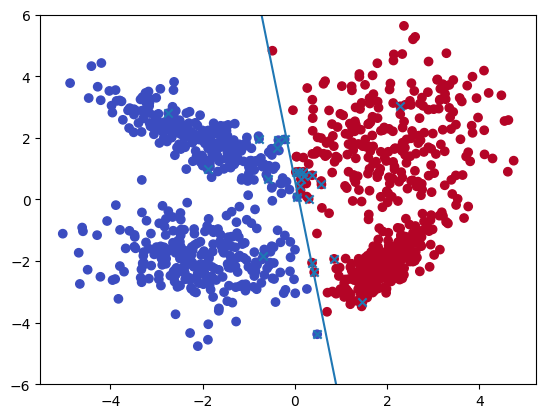

['0.00', '1.00']
['0.99', '0.01']
['0.79', '0.21']
['1.00', '0.00']
['0.00', '1.00']
['0.01', '0.99']
['0.00', '1.00']
['0.94', '0.06']
['1.00', '0.00']
['0.99', '0.01']
['1.00', '0.00']
['0.98', '0.02']
['1.00', '0.00']
['0.98', '0.02']
['0.00', '1.00']
['0.98', '0.02']
['1.00', '0.00']
['1.00', '0.00']
['1.00', '0.00']
['1.00', '0.00']
['0.00', '1.00']
['1.00', '0.00']
['0.09', '0.91']
['0.00', '1.00']
['0.00', '1.00']
['0.01', '0.99']
['0.00', '1.00']
['0.98', '0.02']
['0.99', '0.01']
['1.00', '0.00']
['1.00', '0.00']
['1.00', '0.00']
['0.99', '0.01']
['0.01', '0.99']
['0.01', '0.99']
['0.99', '0.01']
['1.00', '0.00']
['0.03', '0.97']
['0.07', '0.93']
['0.01', '0.99']
['0.00', '1.00']
['1.00', '0.00']
['0.97', '0.03']
['0.00', '1.00']
['0.97', '0.03']
['0.96', '0.04']
['0.96', '0.04']
['0.02', '0.98']
['0.00', '1.00']
['0.00', '1.00']
['0.52', '0.48']
['0.02', '0.98']
['1.00', '0.00']
['0.00', '1.00']
['0.01', '0.99']
['0.00', '1.00']
['0.01', '0.99']
['0.94', '0.06']
['1.00', '0.00

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, Y)
y_pred = model.predict(X)

wrong = pred != Y

acc = accuracy_score(Y, y_pred)
f1 = f1_score(Y, y_pred)

print("Accuracy: ", acc)
print("F1: ", f1)

plt.scatter(X[:, 0], X[:, 1], c=pred, cmap='coolwarm')
plt.scatter(X[wrong, 0], X[wrong, 1],  marker='x')
plt.ylim(-6, 6)
plt.plot(x_val, y_val)
plt.show()

proba = model.predict_proba(X)
for pr in proba:
    pr = list(pr)
    print([f'{i:.2f}' for i in pr])


Accuracy:  0.709
F1:  0.7548441449031171


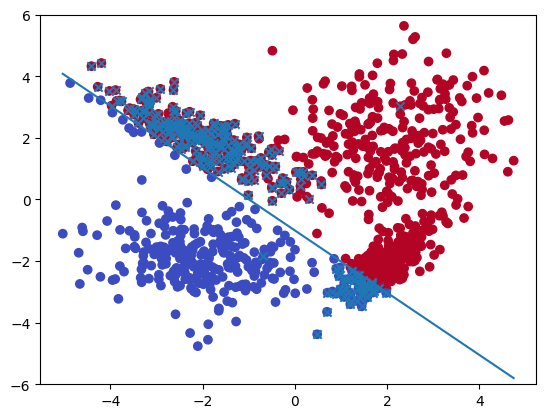

In [5]:
logreg = Logreg(alpha=0.00001)

logreg.fit(X, Y)
pred = logreg.predict(X)
wrong = pred != Y

w0, w1, w2 = logreg.w
x_val =  np.array([X[:, 0].min(), X[:, 0].max()])
y_val = -(w0 + w1 * x_val) / w2

acc = accuracy_score(Y, pred)
f1 = f1_score(Y, pred)

print("Accuracy: ", acc)
print("F1: ", f1)

plt.scatter(X[:, 0], X[:, 1], c=pred, cmap='coolwarm')
plt.scatter(X[wrong, 0], X[wrong, 1],  marker='x')
plt.ylim(-6, 6)
plt.plot(x_val, y_val)
plt.show()

Accuracy:  0.976
F1:  0.9761431411530815


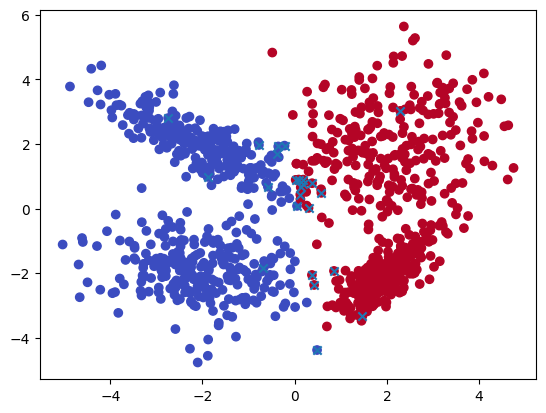

In [6]:
class OvA:
    def __init__(self, base_model):
        self.base_model = base_model
        self.classes = None
        self.models = {}

    def fit(self, X, Y):
        self.classes = np.unique(Y)

        for c in self.classes:
            cls = (Y == c).astype(int)
            model = self.base_model()
            model.fit(X, cls)
            self.models[c] = model

    def predict(self, X):
        probs = np.column_stack([self.models[c].predict_proba(X) for c in self.classes])
        return self.classes[np.argmax(probs, axis=1)]

model_ova = OvA(Logreg)
model_ova.fit(X, Y)
pred = model_ova.predict(X)
wrong = pred != Y

acc = accuracy_score(Y, pred)
f1 = f1_score(Y, pred)

print("Accuracy: ", acc)
print("F1: ", f1)

plt.scatter(X[:, 0], X[:, 1], c=pred, cmap='coolwarm')
plt.scatter(X[wrong, 0], X[wrong, 1], marker='x')
plt.show()

